In [ ]:
import pandas as pd
from pyspark.sql import SparkSession

In [ ]:
from pyspark.sql import SparkSession
import pandas as pd

In [ ]:
spark = SparkSession.builder.appName("HealthEconomics_Analysis").config("spark.sql.execution.arrow.pyspark.enabled", "true").getOrCreate()

#**Mount Google Drive Để Tải File Lên**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Economic-health-BigData/CMS.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Giai Đoạn 1: Khám Phá Và Phân Tích Dữ Liệu**

##**Bước 1: Khám phá và kiểm tra**

**1. Đọc Dữ Liệu**

In [ ]:
df_spark = spark.read.csv(file_path, header=True, inferSchema=True)
print("Đọc dữ liệu thành công!")
    # Hiển thị 5 dòng đầu để kiểm tra
df_spark.show(5)

Đọc dữ liệu thành công!
+----------+--------------------------+-----------------------+---------------+--------------------+-------------------+--------------------+----------------+-----------------+-------------------------+-----------------------+-----------------+-----------------+----------------------+------------------+-----------------+-----------------------------+--------+--------------------+--------------+-------------+---------+---------+------------------+--------------+------------------+-----------------+------------------+
|Rndrng_NPI|Rndrng_Prvdr_Last_Org_Name|Rndrng_Prvdr_First_Name|Rndrng_Prvdr_MI|Rndrng_Prvdr_Crdntls|Rndrng_Prvdr_Ent_Cd|    Rndrng_Prvdr_St1|Rndrng_Prvdr_St2|Rndrng_Prvdr_City|Rndrng_Prvdr_State_Abrvtn|Rndrng_Prvdr_State_FIPS|Rndrng_Prvdr_Zip5|Rndrng_Prvdr_RUCA|Rndrng_Prvdr_RUCA_Desc|Rndrng_Prvdr_Cntry|Rndrng_Prvdr_Type|Rndrng_Prvdr_Mdcr_Prtcptg_Ind|HCPCS_Cd|          HCPCS_Desc|HCPCS_Drug_Ind|Place_Of_Srvc|Tot_Benes|Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_

**2. Xem Cấu Trúc Schema của Dữ liệu**

In [ ]:
print("CẤU TRÚC DỮ LIỆU:")
df_spark.printSchema()

CẤU TRÚC DỮ LIỆU:
root
 |-- Rndrng_NPI: integer (nullable = true)
 |-- Rndrng_Prvdr_Last_Org_Name: string (nullable = true)
 |-- Rndrng_Prvdr_First_Name: string (nullable = true)
 |-- Rndrng_Prvdr_MI: string (nullable = true)
 |-- Rndrng_Prvdr_Crdntls: string (nullable = true)
 |-- Rndrng_Prvdr_Ent_Cd: string (nullable = true)
 |-- Rndrng_Prvdr_St1: string (nullable = true)
 |-- Rndrng_Prvdr_St2: string (nullable = true)
 |-- Rndrng_Prvdr_City: string (nullable = true)
 |-- Rndrng_Prvdr_State_Abrvtn: string (nullable = true)
 |-- Rndrng_Prvdr_State_FIPS: string (nullable = true)
 |-- Rndrng_Prvdr_Zip5: string (nullable = true)
 |-- Rndrng_Prvdr_RUCA: double (nullable = true)
 |-- Rndrng_Prvdr_RUCA_Desc: string (nullable = true)
 |-- Rndrng_Prvdr_Cntry: string (nullable = true)
 |-- Rndrng_Prvdr_Type: string (nullable = true)
 |-- Rndrng_Prvdr_Mdcr_Prtcptg_Ind: string (nullable = true)
 |-- HCPCS_Cd: string (nullable = true)
 |-- HCPCS_Desc: string (nullable = true)
 |-- HCPCS_Drug_Ind:

**Tổng Quan 1:**

1. **Dữ liệu rất giàu:** Có đầy đủ thông tin để làm kinh tế y tế

2. **Tên cột quá dài và khó nhớ:** Ví dụ Rndrng_Prvdr_Last_Org_Name

3. **Kiểu dữ liệu (Data Type):** Spark đã tự động nhận diện double cho các cột tiền tệ (Money).


## **Bước 2: Làm Sạch Dữ Liệu**

**Đổi tên các cột dài dòng thành tên ngắn gọn, dễ hiểu**

In [ ]:
from pyspark.sql.functions import col, trim, upper
df_clean = df_spark.select(

    col("Rndrng_NPI").cast("string").alias("npi"),
    col("Rndrng_Prvdr_Last_Org_Name").alias("last_name_org"),
    col("Rndrng_Prvdr_First_Name").alias("first_name"),
    col("Rndrng_Prvdr_Type").alias("specialty"),
    col("Rndrng_Prvdr_Ent_Cd").alias("entity_type"),

    col("Place_Of_Srvc").alias("place_of_service"),
    col("Rndrng_Prvdr_State_Abrvtn").alias("state"),
    col("Rndrng_Prvdr_City").alias("city"),
    col("Rndrng_Prvdr_RUCA").cast("double").alias("ruca_code"),


    col("HCPCS_Cd").alias("hcpcs_code"),
    col("HCPCS_Desc").alias("description"),
    col("HCPCS_Drug_Ind").alias("is_drug"),


    col("Tot_Benes").cast("integer").alias("total_beneficiaries"),
    col("Tot_Srvcs").cast("double").alias("total_services"),

    col("Avg_Sbmtd_Chrg").cast("double").alias("submitted_price"),
    col("Avg_Mdcr_Alowd_Amt").cast("double").alias("allowed_amount"),
    col("Avg_Mdcr_Pymt_Amt").cast("double").alias("payment_amount")
)

In [ ]:
df_clean.show(50)

+----------+-------------+----------+--------------------+-----------+----------------+-----+---------+---------+----------+--------------------+-------+-------------------+--------------+---------------+--------------+--------------+
|       npi|last_name_org|first_name|           specialty|entity_type|place_of_service|state|     city|ruca_code|hcpcs_code|         description|is_drug|total_beneficiaries|total_services|submitted_price|allowed_amount|payment_amount|
+----------+-------------+----------+--------------------+-----------+----------------+-----+---------+---------+----------+--------------------+-------+-------------------+--------------+---------------+--------------+--------------+
|1003000126|    Enkeshafi|   Ardalan|         Hospitalist|          I|               F|   MD| Bethesda|      1.0|     99221|Initial hospital ...|      N|                 12|          12.0|   250.22666667|       89.0625|       60.3125|
|1003000126|    Enkeshafi|   Ardalan|         Hospitalist|  

In [ ]:
df_clean.count()

9660647

In [ ]:
df_spark.count()

9660647

**Loại bỏ các dòng mà Giá thực trả hoặc Mã dịch vụ bị Null (Dữ liệu rác)**


In [ ]:
#Đếm số lượng Null trong TỪNG CỘT
from pyspark.sql.functions import col, count, when

df_clean.select([count(when(col(c).isNull(), c)).alias(c) for c in df_clean.columns]).show()

+---+-------------+----------+---------+-----------+----------------+-----+----+---------+----------+-----------+-------+-------------------+--------------+---------------+--------------+--------------+
|npi|last_name_org|first_name|specialty|entity_type|place_of_service|state|city|ruca_code|hcpcs_code|description|is_drug|total_beneficiaries|total_services|submitted_price|allowed_amount|payment_amount|
+---+-------------+----------+---------+-----------+----------------+-----+----+---------+----------+-----------+-------+-------------------+--------------+---------------+--------------+--------------+
|  0|            0|    537088|        0|          0|               0|    0|   0|     7600|         0|          0|      0|                  0|             0|              0|             0|             0|
+---+-------------+----------+---------+-----------+----------------+-----+----+---------+----------+-----------+-------+-------------------+--------------+---------------+--------------+-

In [ ]:

# Nếu 1 trong các cột này bị rỗng => xóa luôn dòng đó
df_clean = df_clean.na.drop(subset=["npi", "hcpcs_code", "payment_amount", "specialty"])

In [ ]:
df_clean.select([count(when(col(c).isNull(), c)).alias(c) for c in df_clean.columns]).show()

+---+-------------+----------+---------+-----------+----------------+-----+----+---------+----------+-----------+-------+-------------------+--------------+---------------+--------------+--------------+
|npi|last_name_org|first_name|specialty|entity_type|place_of_service|state|city|ruca_code|hcpcs_code|description|is_drug|total_beneficiaries|total_services|submitted_price|allowed_amount|payment_amount|
+---+-------------+----------+---------+-----------+----------------+-----+----+---------+----------+-----------+-------+-------------------+--------------+---------------+--------------+--------------+
|  0|            0|    537088|        0|          0|               0|    0|   0|     7600|         0|          0|      0|                  0|             0|              0|             0|             0|
+---+-------------+----------+---------+-----------+----------------+-----+----+---------+----------+-----------+-------+-------------------+--------------+---------------+--------------+-

In [ ]:
# Chuẩn hóa chuỗi (Xóa khoảng trắng thừa, viết hoa) để hỗ trợ tính GroupBy
df_clean = df_clean.withColumn("city", upper(trim(col("city"))))

In [ ]:
df_clean.printSchema()
df_clean.show(5, truncate=False)

root
 |-- npi: string (nullable = true)
 |-- last_name_org: string (nullable = true)
 |-- first_name: string (nullable = true)
 |-- specialty: string (nullable = true)
 |-- entity_type: string (nullable = true)
 |-- place_of_service: string (nullable = true)
 |-- state: string (nullable = true)
 |-- city: string (nullable = true)
 |-- ruca_code: double (nullable = true)
 |-- hcpcs_code: string (nullable = true)
 |-- description: string (nullable = true)
 |-- is_drug: string (nullable = true)
 |-- total_beneficiaries: integer (nullable = true)
 |-- total_services: double (nullable = true)
 |-- submitted_price: double (nullable = true)
 |-- allowed_amount: double (nullable = true)
 |-- payment_amount: double (nullable = true)

+----------+-------------+----------+-----------+-----------+----------------+-----+--------+---------+----------+----------------------------------------------------------------------------------------------------------------------------------+-------+------------

**EDA (Khám phá dữ liệu)**

**Có bao nhiêu Chuyên khoa khác nhau trong bộ dữ liệu này? Và chuyên khoa nào có số lượng bác sĩ đông nhất?**

=> Tập trung vào Top các chuyên khoa phổ biến nhất để tối đa hóa "Economic Impact" (Tác động kinh tế)

In [ ]:
df_clean.groupBy("specialty").count().orderBy(col("count").desc()).show(10, truncate=False)

+--------------------------------------+-------+
|specialty                             |count  |
+--------------------------------------+-------+
|Diagnostic Radiology                  |1128876|
|Nurse Practitioner                    |892849 |
|Internal Medicine                     |808835 |
|Family Practice                       |770162 |
|Physician Assistant                   |546322 |
|Physical Therapist in Private Practice|389025 |
|Cardiology                            |381081 |
|Orthopedic Surgery                    |264886 |
|Ophthalmology                         |225826 |
|Emergency Medicine                    |214477 |
+--------------------------------------+-------+
only showing top 10 rows



## **Bước 3: Phân Tích**



**Phân tích nhanh kết quả EDA:**

* Diagnostic Radiology (Chẩn đoán hình ảnh): Đứng top 1 với hơn 1,1 triệu dòng. Đây là mỏ vàng để tìm gian lận vì các dịch vụ chụp chiếu (X-Quang, MRI, CT) có giá rất chuẩn hóa. Nếu ai đó có giá lệch chuẩn, đó là dấu hiệu gian lận cực rõ.

* Cardiology (Tim mạch): Hơn 380.000 dòng. Tuy số lượng ít hơn Radiology nhưng giá trị kinh tế (Economic Value) của mỗi ca tim mạch thường cao gấp hàng chục lần.

* Internal Medicine (Nội khoa): Rất đông, nhưng dịch vụ thường tạp nham, khó tìm quy luật (Noise).


**=> Phát Hiện Gian Lận Trong Chuyên Khoa Tim Mạch và Chẩn Đoán Hình Ảnh Là "Tối Ưu" Nhất**

#**Giai Đoạn 2: Machine Learning Điều Tra Dựa Trên Dữ Liệu Đã Phân Tích**

## **1./ Mô Hình A**

**Mục Tiêu:** So sánh giá và tìm số tìm của chính phủ bị lãng phí

**Ta sẽ hiện thực hóa công thức tính Chi tiêu vượt mức (Excess Spending) trong bài báo khoa học đã được nghiên cứu**

**Tư duy thuật toán:**
1. Với mỗi mã dịch vụ (hcpcs_code) tại mỗi bang (state), ta đi tính giá chuẩn của thị trường. **(Peer Price)**

2. Với mỗi bác sĩ, ta so sánh giá họ đòi (submitted_price) với giá chuẩn đã tìm ở bước trước.

3. Công Thức Áp Dụng:
```
ExcessAmount = (MyPrice - PeerPrice) * TotalServices
```

(***Nếu MyPrice < PeerPrice thì Excess là âm => Bác sĩ tiết kiệm cho nhà nước => Tốt***).




In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, avg, sum as spark_sum, round, desc, abs

In [ ]:
target_specialties = ["Cardiology", "Diagnostic Radiology"]

In [ ]:
#Lấy dữ liệu của Tim Mạch và Chuẩn Đoán
df_focus = df_clean.filter(col("specialty").isin(target_specialties))

In [ ]:
df_focus.show(25)

+----------+-------------+----------+--------------------+-----------+----------------+-----+-------------+---------+----------+--------------------+-------+-------------------+--------------+---------------+--------------+--------------+
|       npi|last_name_org|first_name|           specialty|entity_type|place_of_service|state|         city|ruca_code|hcpcs_code|         description|is_drug|total_beneficiaries|total_services|submitted_price|allowed_amount|payment_amount|
+----------+-------------+----------+--------------------+-----------+----------------+-----+-------------+---------+----------+--------------------+-------+-------------------+--------------+---------------+--------------+--------------+
|1003000936|Stellingworth|      Mark|          Cardiology|          I|               O|   SC|   HARTSVILLE|      5.0|     36415|Insertion of need...|      N|                271|         467.0|    11.60385439|           8.4|           8.4|
|1003000936|Stellingworth|      Mark|       

In [ ]:
df_focus.count()

1509957

**Định nghĩa Peer:** Các bác sĩ cùng làm MỘT DỊCH VỤ tại CÙNG MỘT BANG, Cùng Bệnh Viện/ Phòng Khám

**Lưu ý:** (PartitionBy phải có thêm "specialty" Để không so sánh nhầm giá Bác sĩ Tim với Bác sĩ X-Quang)

In [ ]:
peer_window = Window.partitionBy("specialty", "hcpcs_code", "state", "place_of_service")

**Tìm giá trung bình của payment_amount (giá thực tế bảo hiểm có thể chi trả) cho dịch vụ theo chuyên khoa, dịch vụ, Bang cụ thể**

In [ ]:
df_analysis = df_focus.withColumn(
    "peer_avg_price",
    avg("payment_amount").over(peer_window)
)

In [ ]:
df_analysis.show(55)

+----------+-------------+-----------+----------+-----------+----------------+-----+------------------+---------+----------+--------------------+-------+-------------------+--------------+---------------+--------------+--------------+------------------+
|       npi|last_name_org| first_name| specialty|entity_type|place_of_service|state|              city|ruca_code|hcpcs_code|         description|is_drug|total_beneficiaries|total_services|submitted_price|allowed_amount|payment_amount|    peer_avg_price|
+----------+-------------+-----------+----------+-----------+----------------+-----+------------------+---------+----------+--------------------+-------+-------------------+--------------+---------------+--------------+--------------+------------------+
|1174504351|        Huang|       Paul|Cardiology|          I|               O|   MA|            BOSTON|      1.0|     0121A|Adm sarscv2 bvl 3...|      N|                 14|          14.0|           75.0|         45.13|         45.13|    

**TÍNH TOÁN EXCESS SPENDING (Lãng phí tiền)**

In [ ]:
df_analysis = df_analysis.withColumn(
    "price_diff",
    col("payment_amount") - col("peer_avg_price")
).withColumn(
    "excess_spending_per_service",
    col("price_diff") * col("total_services")
)

In [ ]:
df_analysis.show(25)

+----------+-------------+----------+----------+-----------+----------------+-----+------------------+---------+----------+--------------------+-------+-------------------+--------------+---------------+--------------+--------------+------------------+--------------------+---------------------------+
|       npi|last_name_org|first_name| specialty|entity_type|place_of_service|state|              city|ruca_code|hcpcs_code|         description|is_drug|total_beneficiaries|total_services|submitted_price|allowed_amount|payment_amount|    peer_avg_price|          price_diff|excess_spending_per_service|
+----------+-------------+----------+----------+-----------+----------------+-----+------------------+---------+----------+--------------------+-------+-------------------+--------------+---------------+--------------+--------------+------------------+--------------------+---------------------------+
|1174504351|        Huang|      Paul|Cardiology|          I|               O|   MA|           

**Tổng hợp thiệt hại** => Bảng Kết Quả

In [ ]:
df_fraud_ranking = df_analysis.groupBy(
    "npi", "last_name_org", "first_name", "city", "state", "specialty"
).agg(
    round(spark_sum("excess_spending_per_service"), 2).alias("total_wasted_money"),
    spark_sum("total_services").alias("total_services")
)

In [ ]:
df_fraud_ranking.show(25)

+----------+--------------+----------+-------------+-----+----------+------------------+--------------+
|       npi| last_name_org|first_name|         city|state| specialty|total_wasted_money|total_services|
+----------+--------------+----------+-------------+-----+----------+------------------+--------------+
|1962695668|      Robinson|      Eric|       SEARCY|   AR|Cardiology|          -34490.6|        3580.0|
|1912987959|       Naddour|      Fadi|       WARREN|   OH|Cardiology|           57114.6|        5802.0|
|1699722397|  Pashmforoush|  Mohammad|    OCEANSIDE|   CA|Cardiology|           2775.39|        4061.0|
|1619953536|    Capodilupo|    Robert|   MANCHESTER|   NH|Cardiology|            482.34|        1811.0|
|1487857470|      Aggarwal|  Himanshu|      CLANTON|   AL|Cardiology|          -9662.92|        3134.0|
|1669628319|       Alomari|      Ihab|MISSION VIEJO|   CA|Cardiology|            390.17|        1191.0|
|1558526285|         Habib|     Ammar|      MERRIAM|   KS|Cardio

**TỔNG HỢP THEO BÁC SĨ (RANKING)**

(xem Bác sĩ nào gây lãng phí tổng cộng lớn nhất)

**Các Bác Sĩ Tim Mạch**

In [ ]:
df_fraud_ranking.filter(col("specialty") == "Cardiology") \
    .orderBy(col("total_wasted_money").desc()).show(5, truncate=False)

+----------+-------------+----------+------------+-----+----------+------------------+--------------+
|npi       |last_name_org|first_name|city        |state|specialty |total_wasted_money|total_services|
+----------+-------------+----------+------------+-----+----------+------------------+--------------+
|1811189822|Gabrielian   |Victor    |ARCADIA     |CA   |Cardiology|835910.01         |18745.0       |
|1164412789|Fileccia     |Russell   |SHREVEPORT  |LA   |Cardiology|470521.17         |12703.0       |
|1649486168|Agarwal      |Rajiv     |HUMBLE      |TX   |Cardiology|438437.22         |49960.0       |
|1316949720|Shapiro      |Barry     |VINELAND    |NJ   |Cardiology|438267.96         |10782.0       |
|1811939085|Musso        |Joseph    |HOWARD BEACH|NY   |Cardiology|435868.34         |9551.0        |
+----------+-------------+----------+------------+-----+----------+------------------+--------------+
only showing top 5 rows



**Các Bác Sĩ Chuẩn Đoán**

In [ ]:
df_fraud_ranking.filter(col("specialty") == "Diagnostic Radiology") \
    .orderBy(col("total_wasted_money").desc()).show(5, truncate=False)

+----------+-------------+----------+----------------------+-----+--------------------+------------------+--------------+
|npi       |last_name_org|first_name|city                  |state|specialty           |total_wasted_money|total_services|
+----------+-------------+----------+----------------------+-----+--------------------+------------------+--------------+
|1992913941|Goodwich     |Ronald    |FORT MYERS            |FL   |Diagnostic Radiology|1534487.95        |268896.0      |
|1912115023|Abraham      |Tony      |PORT JEFFERSON STATION|NY   |Diagnostic Radiology|1453485.69        |14270.8       |
|1720050040|Solomon      |Robert    |BROOKLYN              |NY   |Diagnostic Radiology|773828.33         |57564.0       |
|1164622353|Gelaw        |Bethlehem |LENEXA                |KS   |Diagnostic Radiology|686414.45         |104490.0      |
|1679546931|Schekall     |Michael   |HUTCHINSON            |KS   |Diagnostic Radiology|551102.32         |129554.0      |
+----------+------------

## **2./ Mô Hình B**

**Mục Tiêu:** Tìm doanh thu bất minh

**Bước 1: Chuẩn bị Dữ Liệu**

**Gom tất cả về dịch vụ khám, chữa bệnh của bác sĩ lại thành 1 dòng:**
- ( excess_spending_per_service ) thành model_c_score tức là số tiền gian lận bảo hiểm, hay còn gọi là (total_wasted_money) ở giai đoạn 1
- (total_actual_payment) là số tiền lương của bác sĩ trong năm qua bằng

In [ ]:
from pyspark.sql.functions import sum as spark_sum, first

# Gom nhóm dữ liệu theo Bác sĩ (NPI) để chạy ML
df_provider_features = df_analysis.groupBy("npi").agg(
    first("last_name_org").alias("name"),
    first("specialty").alias("specialty"),
    first("state").alias("state"),
    spark_sum("total_services").alias("total_services"),
    spark_sum("total_beneficiaries").alias("total_beneficiaries"),
    # Tổng tiền thực nhận = sum(payment_amount * total_services)
    spark_sum(col("payment_amount") * col("total_services")).alias("total_actual_payment"),
    spark_sum("excess_spending_per_service").alias("model_a_score")
).na.drop()

print(f"Số lượng bác sĩ để chạy mô hình: {df_provider_features.count()}")

Số lượng bác sĩ để chạy mô hình: 50953


In [ ]:
df_provider_features.show(20)

+----------+-------------+--------------------+-----+--------------+-------------------+--------------------+-------------------+
|       npi|         name|           specialty|state|total_services|total_beneficiaries|total_actual_payment|      model_a_score|
+----------+-------------+--------------------+-----+--------------+-------------------+--------------------+-------------------+
|1003002783|      Hartman|Diagnostic Radiology|   PA|        4549.0|               1268|   59399.15000017709|  3052.951336738508|
|1003002809|     Graziano|Diagnostic Radiology|   NY|        3315.0|               1491|  255563.14000018846|  53143.47732898471|
|1003006107|      Al-Saab|          Cardiology|   TX|         329.0|                215|  23027.680000177003|  921.0091076414344|
|1003007170|       Danciu|          Cardiology|   IL|        1797.0|               1574|   151352.8799998022| 13150.762381603465|
|1003007204|       Yamani|          Cardiology|   TX|        4231.0|               2143|  

**Bước 2: Xây dựng mô hình**

(**Mục tiêu:** Tìm ra những người kiếm tiền nhiều bất thường so với khối lượng công việc)

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import VectorAssembler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

**Hàm Huấn Luyện**

**Phương Trình:**

`Doanh thu dự đoán = (A * số dịch vụ) + (B * số bệnh nhân) + C`

**Trong đó:**
- **Số Dịch vụ (total_services) & Số Bệnh nhân (total_beneficiaries):** Là dữ liệu đầu vào thực tế của từng bác sĩ.
- **A, B, C:** Là các Hệ số (Coefficients) mà máy tính đã tự tìm ra sau khi quan sát toàn bộ dữ liệu thị trường (Quá trình fit).

In [ ]:
def train_specialty_model(df_input, specialty_name):
    print(f"HUẤN LUYỆN MÔ HÌNH CHO: {specialty_name.upper()}...")

    # 1. Lọc dữ liệu riêng cho chuyên khoa này
    df_spec = df_input.filter(col("specialty") == specialty_name)

    # 2. Tạo Vector đặc trưng
    assembler = VectorAssembler(
        inputCols=["total_services", "total_beneficiaries"],
        outputCol="features_reg"
    )
    df_vec = assembler.transform(df_spec)

    # 3. Huấn luyện Linear Regression
    lr = LinearRegression(featuresCol="features_reg", labelCol="total_actual_payment")
    model = lr.fit(df_vec)

    # 4. Dự đoán & Tính điểm
    df_result = model.transform(df_vec).withColumn(
        "model_b_score", col("total_actual_payment") - col("prediction")
    )

    return df_result, model

**Chuyên Khoa Tim Mạch**

In [ ]:
df_model_b_cardio, model_cardio = train_specialty_model(df_provider_features, "Cardiology")

HUẤN LUYỆN MÔ HÌNH CHO: CARDIOLOGY...


**Chuyên Khoa Chuẩn Đoán**

In [ ]:
# Chạy cho Chẩn đoán hình ảnh
df_model_b_radio, model_radio = train_specialty_model(df_provider_features, "Diagnostic Radiology")

HUẤN LUYỆN MÔ HÌNH CHO: DIAGNOSTIC RADIOLOGY...


In [ ]:
# GỘP KẾT QUẢ LẠI
df_model_b_final = df_model_b_cardio.union(df_model_b_radio)

In [ ]:
print("\n=== KẾT QUẢ MÔ HÌNH B (ĐÃ TÁCH BIỆT CHUYÊN KHOA) ===")
df_model_b_final.select("name", "specialty", "total_actual_payment", "prediction", "model_b_score") \
    .orderBy(col("model_b_score").desc()).show(5)


=== KẾT QUẢ MÔ HÌNH B (ĐÃ TÁCH BIỆT CHUYÊN KHOA) ===
+-------+--------------------+--------------------+------------------+--------------------+
|   name|           specialty|total_actual_payment|        prediction|       model_b_score|
+-------+--------------------+--------------------+------------------+--------------------+
| Morris|Diagnostic Radiology| 1.195493653022341E7|441761.42203420115| 1.151317510818921E7|
|     Le|Diagnostic Radiology|1.0670096599971319E7| 332931.5160910174|1.0337165083880302E7|
|Abraham|Diagnostic Radiology|   7551011.900134425| 263916.7452077793|   7287095.154926646|
|Solomon|Diagnostic Radiology|  6999020.1199741475| 1573734.463571902|   5425285.656402245|
|  Salem|Diagnostic Radiology|   5049287.110006813|115424.36162535893|  4933862.7483814545|
+-------+--------------------+--------------------+------------------+--------------------+
only showing top 5 rows



**Top 5 Bác sĩ có doanh thu cao bất thường - Chuyên khoa Chẩn đoán Hình ảnh (Diagnostic Radiology)**

In [ ]:
df_model_b_final.filter(col("specialty") == "Diagnostic Radiology") \
    .select("name", "specialty", round("total_actual_payment", 2).alias("total_actual_payment"), round("prediction", 2).alias("prediction"), round("model_b_score", 2).alias("model_b_score")) \
    .orderBy(col("model_b_score").desc()).show(5, truncate=False)

+-------+--------------------+--------------------+----------+-------------+
|name   |specialty           |total_actual_payment|prediction|model_b_score|
+-------+--------------------+--------------------+----------+-------------+
|Morris |Diagnostic Radiology|1.195493653E7       |441761.42 |1.151317511E7|
|Le     |Diagnostic Radiology|1.06700966E7        |332931.52 |1.033716508E7|
|Abraham|Diagnostic Radiology|7551011.9           |263916.75 |7287095.15   |
|Solomon|Diagnostic Radiology|6999020.12          |1573734.46|5425285.66   |
|Salem  |Diagnostic Radiology|5049287.11          |115424.36 |4933862.75   |
+-------+--------------------+--------------------+----------+-------------+
only showing top 5 rows



**Top 5 Bác sĩ có doanh thu cao bất thường - Chuyên khoa Tim mạch (Cardiology)**

In [ ]:
df_model_b_final.filter(col("specialty") == "Cardiology") \
    .select("name", "specialty", round("total_actual_payment", 2).alias("total_actual_payment"), round("prediction", 2).alias("prediction"), round("model_b_score", 2).alias("model_b_score")) \
    .orderBy(col("model_b_score").desc()).show(5, truncate=False)

+----------+----------+--------------------+----------+-------------+
|name      |specialty |total_actual_payment|prediction|model_b_score|
+----------+----------+--------------------+----------+-------------+
|Khorsandi |Cardiology|6058904.62          |1331589.42|4727315.2    |
|Singh     |Cardiology|4720533.82          |301931.03 |4418602.79   |
|Polosajian|Cardiology|6044103.63          |2092554.82|3951548.81   |
|Borromeo  |Cardiology|4301803.39          |414534.34 |3887269.05   |
|Gabrielian|Cardiology|5002437.13          |1195419.79|3807017.34   |
+----------+----------+--------------------+----------+-------------+
only showing top 5 rows



##**3./ Mô Hình C**

**Mục Tiêu:** Tìm kiếm Sự phá vỡ quy luật phân phối tự nhiên.

Ba thuộc tính (**total_services**, **total_beneficiaries**, **total_actual_payment**) định hình nên chân dung của 1 bác sĩ **=>** Bất kỳ sự gian lận nào đều sẽ làm 1 trong 3 thuộc tính này phình lên

**Dùng PCA (Principal Component Analysis) để tìm bất thường.**

**Kết quả trả về là một con số cho mỗi bác sĩ (model_b_score):**
- Nếu Điểm thấp (0 - 3): $\rightarrow$ Bác sĩ Bình thường. Hành vi của họ giống 99% đồng nghiệp. (Làm việc vừa sức, thu nhập vừa phải).
- Nếu Điểm cao vọt (10 - 50+): $\rightarrow$ Kẻ Dị Biệt (Anomaly).

In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.sql.functions import col, udf, abs as spark_abs
from pyspark.sql.types import FloatType

In [ ]:
# Hàm trích xuất giá trị từ Vector (Dùng chung)
extract_first_element = udf(lambda v: float(v[0]), FloatType())

In [ ]:
def train_specialty_pca(df_input, specialty_name):

    # 1. Lọc dữ liệu riêng
    df_spec = df_input.filter(col("specialty") == specialty_name)

    # 2. Vector hóa
    assembler = VectorAssembler(
        inputCols=["total_services", "total_beneficiaries", "total_actual_payment"],
        outputCol="features_raw_pca"
    )
    df_vec = assembler.transform(df_spec)

    # 3. Chuẩn hóa về độ lệch chuẩn
    scaler = StandardScaler(
        inputCol="features_raw_pca",
        outputCol="features_pca",
        withStd=True,
        withMean=True
    )
    scaler_model = scaler.fit(df_vec)
    df_scaled = scaler_model.transform(df_vec)

    # 4. Chạy PCA (Học cấu trúc riêng của nhóm đó)
    pca = PCA(k=1, inputCol="features_pca", outputCol="pca_features")
    pca_model = pca.fit(df_scaled)
    df_pca_result = pca_model.transform(df_scaled)

    # 5. Tính điểm dị biệt
    df_result = df_pca_result.withColumn(
        "model_c_score",
        spark_abs(extract_first_element("pca_features"))
    )

    # Chỉ lấy các cột cần thiết để trả về
    return df_result.select("npi", "name", "specialty", "state", "total_services", "total_actual_payment", "model_c_score")

**Chạy Thực Tế**

In [ ]:
# 1. Chạy cho Tim mạch
df_model_c_cardio = train_specialty_pca(df_provider_features, "Cardiology")

In [ ]:
# 2. Chạy cho Chẩn đoán hình ảnh
df_model_c_radio = train_specialty_pca(df_provider_features, "Diagnostic Radiology")

In [ ]:
# 3. Gộp kết quả lại
df_model_c_final = df_model_c_cardio.union(df_model_c_radio)

In [ ]:
df_model_c_final.filter(col("specialty") == "Cardiology") \
    .select("name", "specialty", round("total_actual_payment", 2).alias("total_actual_payment"), round("model_c_score", 2).alias("model_c_score")) \
    .orderBy(col("model_c_score").desc()).show(5, truncate=False)

+----------+----------+--------------------+-------------+
|name      |specialty |total_actual_payment|model_c_score|
+----------+----------+--------------------+-------------+
|Emrani    |Cardiology|5000304.19          |53.03        |
|Appelbaum |Cardiology|660899.98           |39.38        |
|Patel     |Cardiology|1494313.87          |26.19        |
|Polosajian|Cardiology|6044103.63          |22.26        |
|Ansari    |Cardiology|4387873.41          |19.37        |
+----------+----------+--------------------+-------------+
only showing top 5 rows



In [ ]:
df_model_c_final.filter(col("specialty") == "Diagnostic Radiology") \
    .select("name", "specialty", round("total_actual_payment", 2).alias("total_actual_payment"), round("model_c_score", 2).alias("model_c_score")) \
    .orderBy(col("model_c_score").desc()).show(5, truncate=False)

+--------+--------------------+--------------------+-------------+
|name    |specialty           |total_actual_payment|model_c_score|
+--------+--------------------+--------------------+-------------+
|Morris  |Diagnostic Radiology|1.195493653E7       |39.72        |
|Le      |Diagnostic Radiology|1.06700966E7        |34.97        |
|Solomon |Diagnostic Radiology|6999020.12          |34.32        |
|Goodwich|Diagnostic Radiology|5711079.0           |31.17        |
|Abraham |Diagnostic Radiology|7551011.9           |24.59        |
+--------+--------------------+--------------------+-------------+
only showing top 5 rows



**Trực quan hóa Mô Hình C**

**Bác sĩ chuyên khoa Tim Mạch**

In [ ]:
df_cardio_only = df_model_c_final.filter(col("specialty") == "Cardiology")

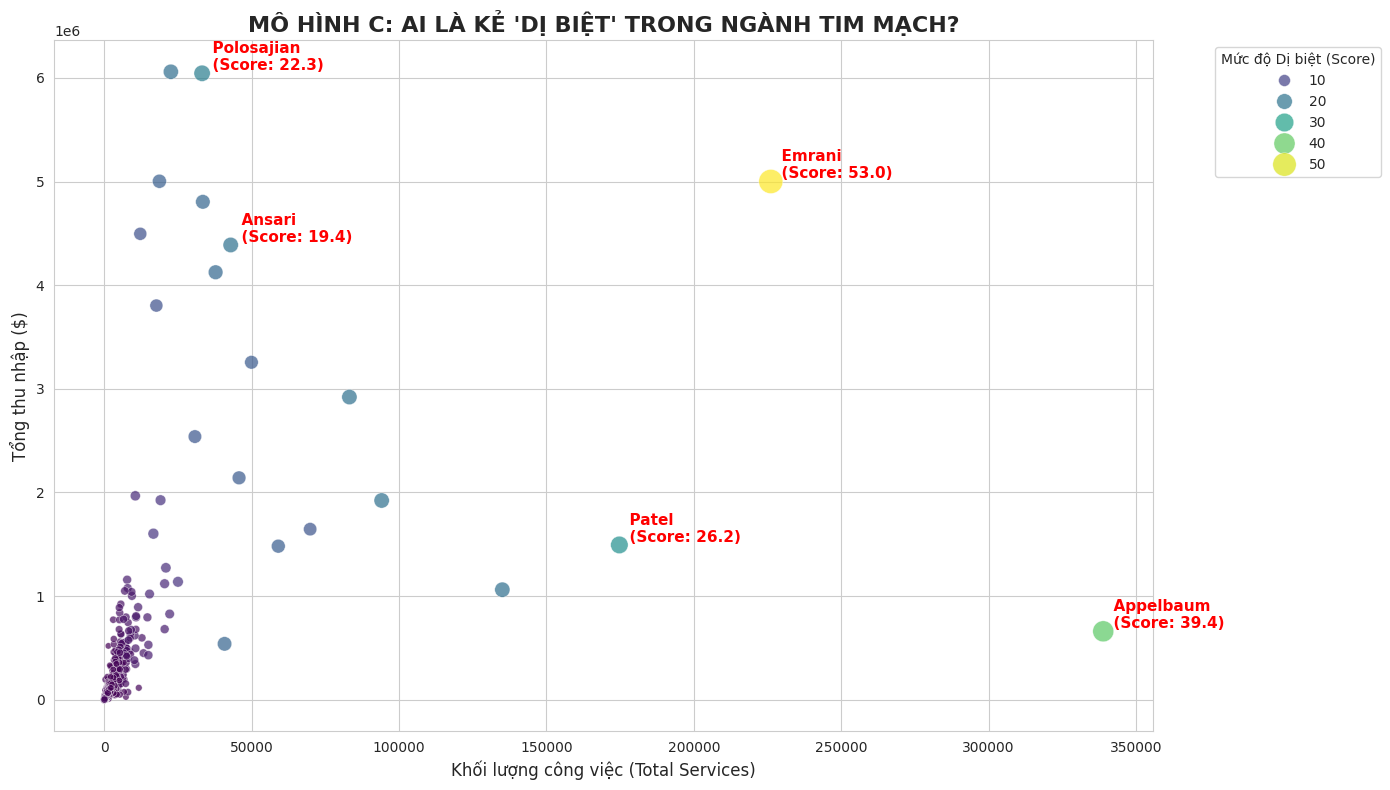

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. CHUẨN BỊ DỮ LIỆU
# Lấy Top 20 kẻ dị biệt + 1000 người bình thường để so sánh
top_anomalies = df_cardio_only.orderBy(col("model_c_score").desc()).limit(20)
random_normal = df_cardio_only.sample(False, 0.1).limit(1000)

# Gộp lại thành pandas dataframe để vẽ
pdf_viz = top_anomalies.union(random_normal).dropDuplicates(["name"]).toPandas()

# 2. VẼ BIỂU ĐỒ PHÂN TÁN (SCATTER PLOT)
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Vẽ các điểm
# Hue (Màu): Dựa trên điểm Score (Càng đỏ càng dị)
# Size (Kích thước): Điểm càng cao chấm càng to
scatter = sns.scatterplot(
    data=pdf_viz,
    x="total_services",
    y="total_actual_payment",
    hue="model_c_score",
    palette="viridis", # Màu từ Tím (Thấp) -> Vàng (Cao)
    size="model_c_score",
    sizes=(20, 300),
    alpha=0.7
)

# 3. GẮN TÊN CHO TOP 5 "QUÁI VẬT"
# Lấy lại Top 5 từ pandas df để gắn nhãn
top_5 = pdf_viz.nlargest(5, 'model_c_score')

for i in range(len(top_5)):
    row = top_5.iloc[i]
    plt.text(
        row['total_services'],
        row['total_actual_payment'],
        f"  {row['name']}\n  (Score: {row['model_c_score']:.1f})",
        fontsize=11,
        color='red',
        weight='bold',
        va='bottom'
    )

# Trang trí
plt.title("MÔ HÌNH C: AI LÀ KẺ 'DỊ BIỆT' TRONG NGÀNH TIM MẠCH?", fontsize=16, fontweight='bold')
plt.xlabel("Khối lượng công việc (Total Services)", fontsize=12)
plt.ylabel("Tổng thu nhập ($)", fontsize=12)
plt.legend(title="Mức độ Dị biệt (Score)", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Bác sĩ chuyên khoa Chuẩn đoán**

In [ ]:
df_diagnostic_radiology_only = df_model_c_final.filter(col("specialty") == "Diagnostic Radiology")

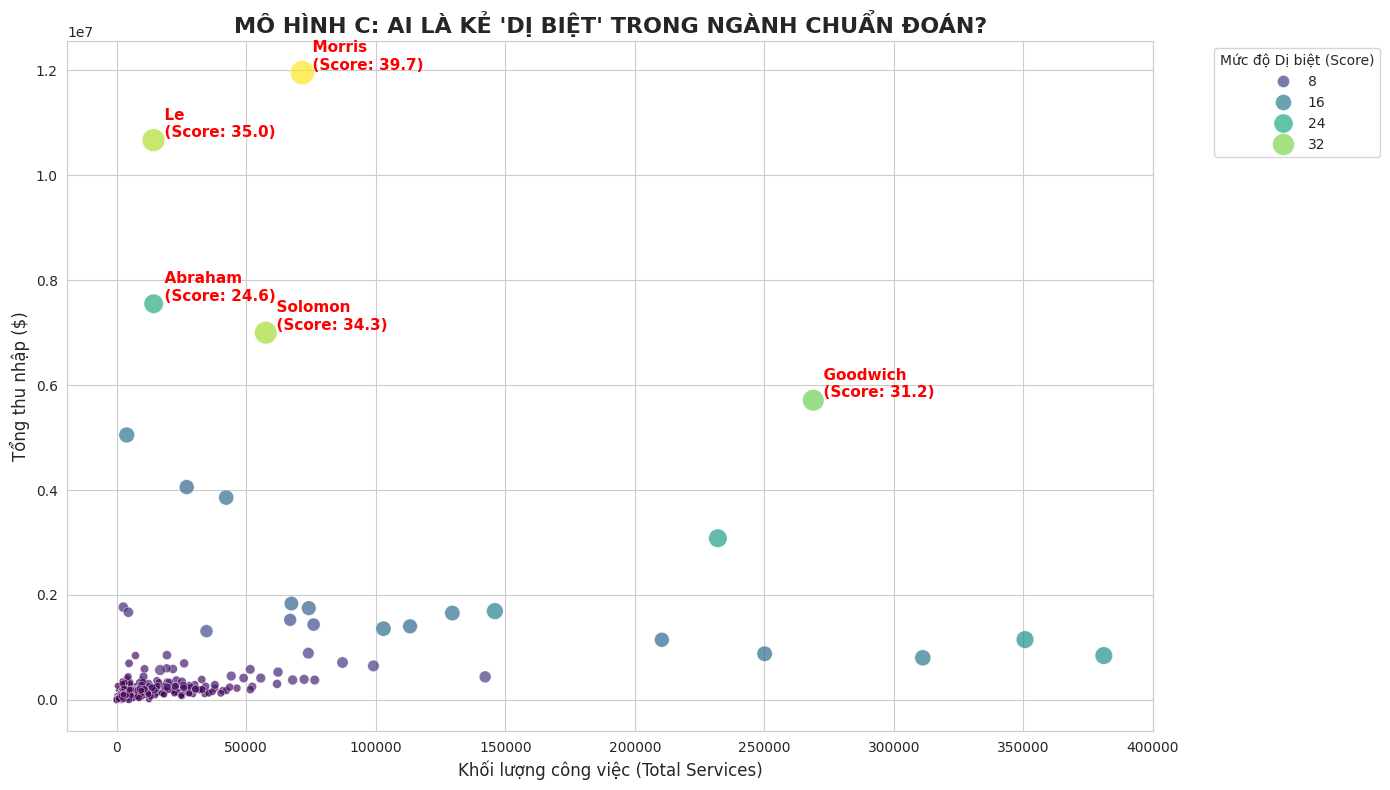

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. CHUẨN BỊ DỮ LIỆU
# Lấy Top 20 kẻ dị biệt + 1000 người bình thường để so sánh
top_anomalies = df_diagnostic_radiology_only.orderBy(col("model_c_score").desc()).limit(20)
random_normal = df_diagnostic_radiology_only.sample(False, 0.1).limit(1000)

# Gộp lại thành pandas dataframe để vẽ
pdf_viz = top_anomalies.union(random_normal).dropDuplicates(["name"]).toPandas()

# 2. VẼ BIỂU ĐỒ PHÂN TÁN (SCATTER PLOT)
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Vẽ các điểm
# Hue (Màu): Dựa trên điểm Score (Càng đỏ càng dị)
# Size (Kích thước): Điểm càng cao chấm càng to
scatter = sns.scatterplot(
    data=pdf_viz,
    x="total_services",
    y="total_actual_payment",
    hue="model_c_score",
    palette="viridis", # Màu từ Tím (Thấp) -> Vàng (Cao)
    size="model_c_score",
    sizes=(20, 300),
    alpha=0.7
)

# 3. GẮN TÊN CHO TOP 5 "QUÁI VẬT"
# Lấy lại Top 5 từ pandas df để gắn nhãn
top_5 = pdf_viz.nlargest(5, 'model_c_score')

for i in range(len(top_5)):
    row = top_5.iloc[i]
    plt.text(
        row['total_services'],
        row['total_actual_payment'],
        f"  {row['name']}\n  (Score: {row['model_c_score']:.1f})",
        fontsize=11,
        color='red',
        weight='bold',
        va='bottom'
    )

# Trang trí
plt.title("MÔ HÌNH C: AI LÀ KẺ 'DỊ BIỆT' TRONG NGÀNH CHUẨN ĐOÁN?", fontsize=16, fontweight='bold')
plt.xlabel("Khối lượng công việc (Total Services)", fontsize=12)
plt.ylabel("Tổng thu nhập ($)", fontsize=12)
plt.legend(title="Mức độ Dị biệt (Score)", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()